# **Financial Modelling and Valuation**

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

from src.config import get_path, BRAND_COLORS, FIN_MODEL_PARAMS
from src.financial_model import (
    project_users, project_revenue, project_income_statement,
    sensitivity_revenue, sensitivity_ebitda, comparable_valuation,
    export_to_excel,
)
from src.viz import apply_project_style, save_figure

apply_project_style()
tables_dir    = get_path("reports_tables")
processed_dir = get_path("data_processed")
print("Setup complete.")

Setup complete.


## Model Assumptions Review

Before building the model, I explicitly stated every assumption.
All assumptions are in `configs/config.yaml` and can be changed there.

In [2]:
print("FINANCIAL MODEL ASSUMPTIONS (from configs/config.yaml)")
print("="*60)
print(f"  Year 1 user target      : {FIN_MODEL_PARAMS['user_base_y1']:,}")
print(f"  Year 2 user growth rate : {FIN_MODEL_PARAMS['user_growth_rate_y2']*100:.0f}%")
print(f"  Year 3 user growth rate : {FIN_MODEL_PARAMS['user_growth_rate_y3']*100:.0f}%")
print(f"  Annual churn rate       : {FIN_MODEL_PARAMS['churn_rate']*100:.0f}%")
print(f"  ARPU Year 1 (USD)       : ${FIN_MODEL_PARAMS['arpu_usd_y1']:.2f}")
print(f"  ARPU growth/year        : {FIN_MODEL_PARAMS['arpu_growth_rate']*100:.0f}%")
print()
print("Revenue Mix:")
for k, v in FIN_MODEL_PARAMS['revenue_mix'].items():
    print(f"  {k:<30} : {v*100:.0f}%")
print()
print("Cost Structure (% of revenue):")
for k, v in FIN_MODEL_PARAMS['opex'].items():
    print(f"  {k:<30} : {v*100:.0f}%")

FINANCIAL MODEL ASSUMPTIONS (from configs/config.yaml)
  Year 1 user target      : 500,000
  Year 2 user growth rate : 80%
  Year 3 user growth rate : 60%
  Annual churn rate       : 18%
  ARPU Year 1 (USD)       : $12.00
  ARPU growth/year        : 15%

Revenue Mix:
  transaction_fees_pct           : 55%
  float_income_pct               : 20%
  lending_pct                    : 15%
  subscription_pct               : 10%

Cost Structure (% of revenue):
  cost_of_revenue_pct            : 40%
  personnel_pct                  : 25%
  tech_infrastructure_pct        : 10%
  marketing_pct                  : 12%
  regulatory_compliance_pct      : 5%
  other_pct                      : 3%


## User Growth Projection

USER GROWTH MODEL:


,year,new_users,churned_users,active_users
0,1,"500,000","90,000","500,000"
1,2,"400,000","90,000","810,000"
2,3,"486,000","145,800","1,150,200"


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig10_user_growth.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig10_user_growth.pdf


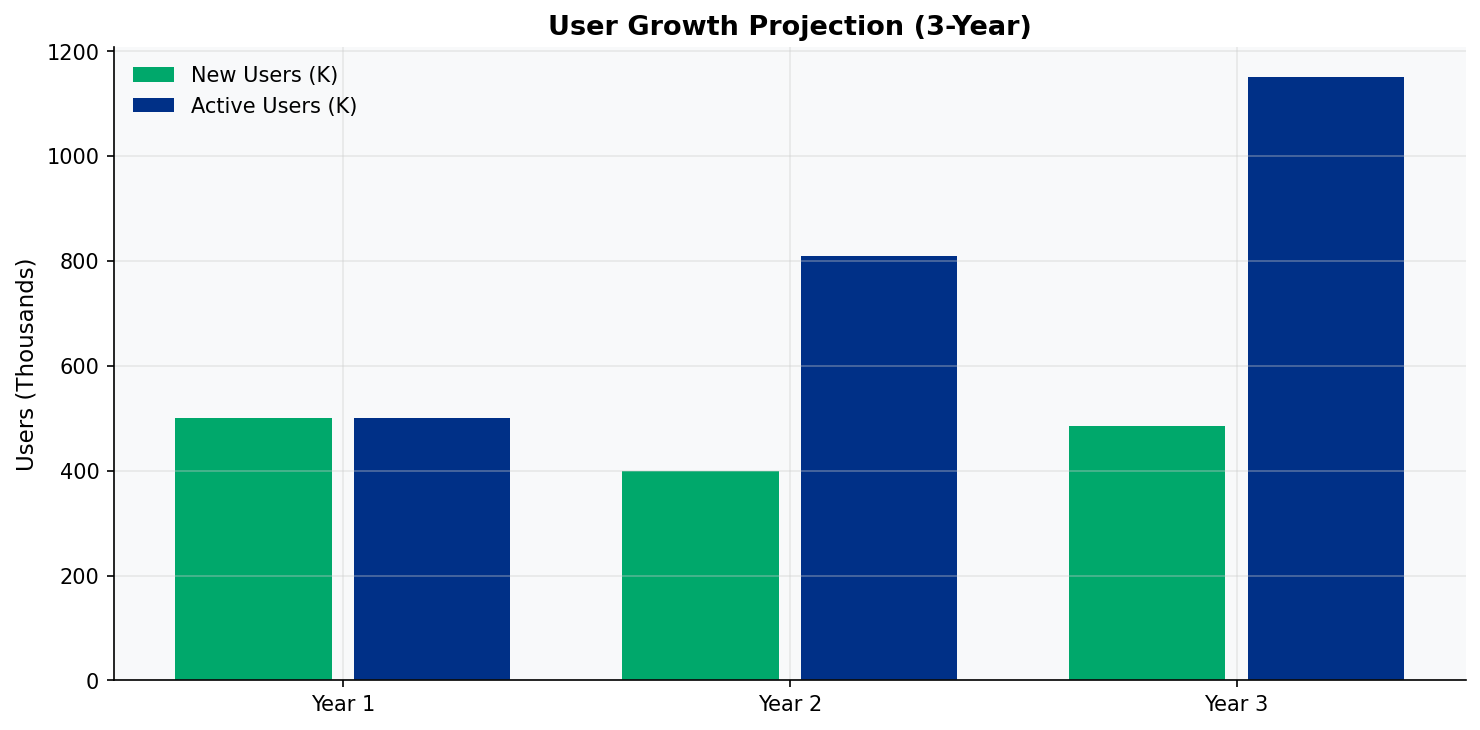

In [3]:
df_users = project_users()
print("USER GROWTH MODEL:")
display(df_users.assign(
    new_users=df_users['new_users'].apply(lambda x: f'{x:,}'),
    churned_users=df_users['churned_users'].apply(lambda x: f'{x:,}'),
    active_users=df_users['active_users'].apply(lambda x: f'{x:,}')
))

# Chart: user growth waterfall
fig, ax = plt.subplots(figsize=(10, 5))
years = df_users['year'].values
ax.bar(years - 0.2, df_users['new_users']/1e3,  0.35, label='New Users (K)', color=BRAND_COLORS['secondary'])
ax.bar(years + 0.2, df_users['active_users']/1e3, 0.35, label='Active Users (K)', color=BRAND_COLORS['primary'])
ax.set_xticks(years)
ax.set_xticklabels(['Year 1', 'Year 2', 'Year 3'])
ax.set_ylabel("Users (Thousands)")
ax.set_title("User Growth Projection (3-Year)")
ax.legend()
plt.tight_layout()
save_figure(fig, "fig10_user_growth.png")
plt.show()

## Revenue Projection by Stream

REVENUE PROJECTION (USD M):


,year,active_users,arpu_usd,total_revenue_usd_m,txn_fees_usd_m,float_income_usd_m,lending_usd_m,subscription_usd_m
0,1,500000,12.00,6.000,3.300,1.200,0.900,0.600
1,2,810000,13.80,11.178,6.148,2.236,1.677,1.118
2,3,1150200,15.87,18.254,10.040,3.651,2.738,1.825


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig11_revenue_by_stream.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig11_revenue_by_stream.pdf


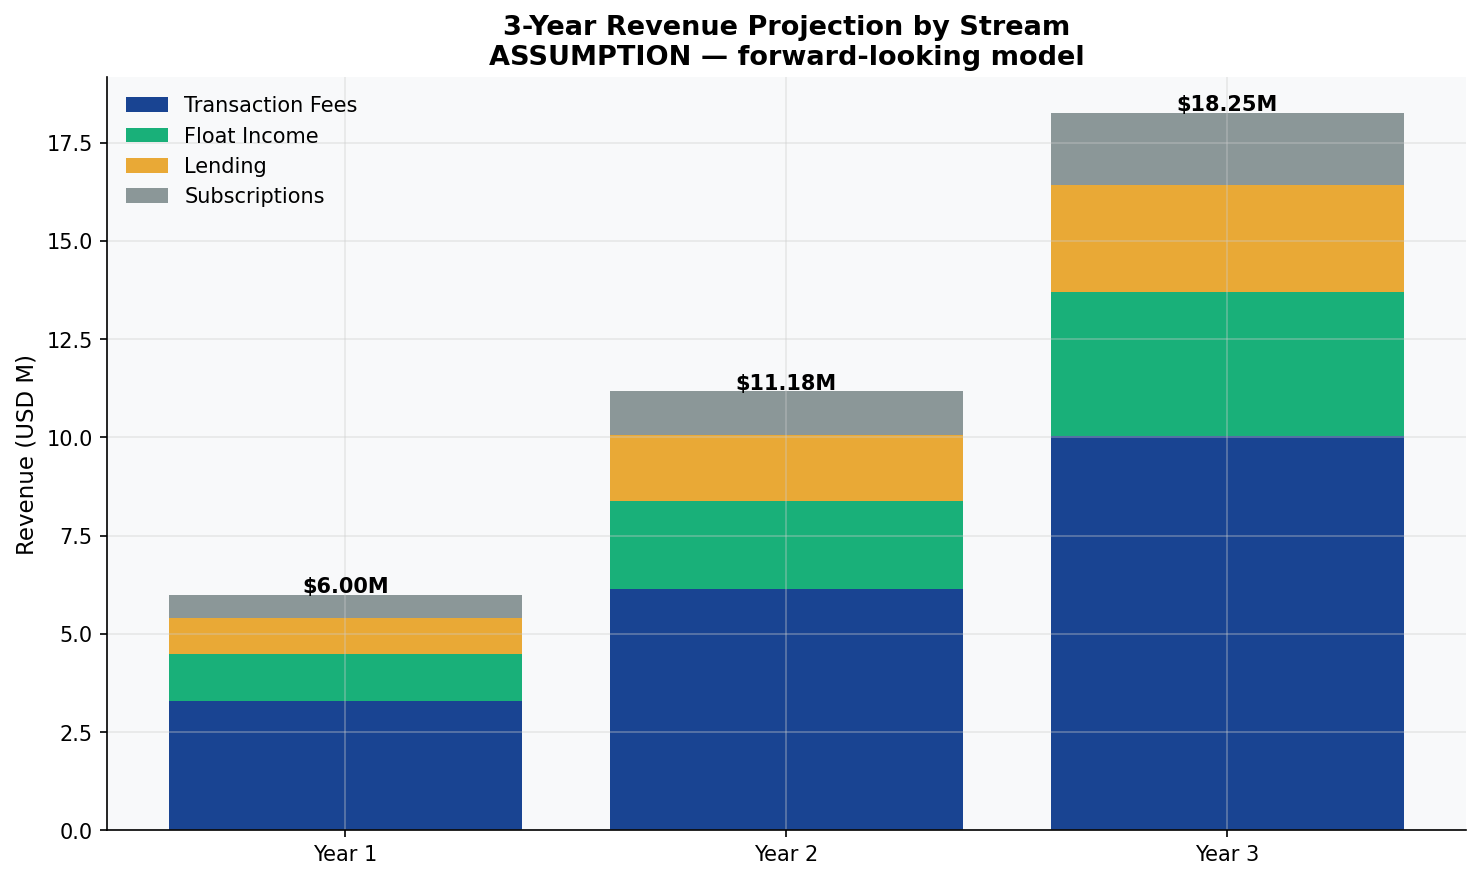

In [4]:
df_revenue = project_revenue(df_users)
print("REVENUE PROJECTION (USD M):")
display(df_revenue)

# Stacked bar chart by revenue stream
fig, ax = plt.subplots(figsize=(10, 6))
streams = ['txn_fees_usd_m', 'float_income_usd_m', 'lending_usd_m', 'subscription_usd_m']
stream_labels = ['Transaction Fees', 'Float Income', 'Lending', 'Subscriptions']
colors = [BRAND_COLORS['primary'], BRAND_COLORS['secondary'],
           BRAND_COLORS['accent'], BRAND_COLORS['neutral']]

bottom = np.zeros(3)
for col, label, color in zip(streams, stream_labels, colors):
    vals = df_revenue[col].values
    ax.bar(['Year 1', 'Year 2', 'Year 3'], vals, bottom=bottom, label=label, color=color, alpha=0.9)
    bottom += vals

ax.set_ylabel("Revenue (USD M)")
ax.set_title("3-Year Revenue Projection by Stream\nASSUMPTION — forward-looking model")
ax.legend(loc='upper left')

# Add total labels
for i, (yr, row) in enumerate(df_revenue.iterrows()):
    ax.text(i, row['total_revenue_usd_m'] + 0.05,
            f"${row['total_revenue_usd_m']:.2f}M", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
save_figure(fig, "fig11_revenue_by_stream.png")
plt.show()

## Income Statement (P&L)

In [5]:
df_pnl = project_income_statement(df_revenue)

print("INCOME STATEMENT (USD M) — ASSUMPTION: Forward-looking model")
display(df_pnl[['year', 'revenue_usd_m', 'cogs_usd_m', 'gross_profit_usd_m',
                  'total_opex_usd_m', 'ebitda_usd_m', 'ebitda_margin_pct']])

# Save to reports
df_pnl.to_csv(tables_dir / "income_statement_projection.csv", index=False)

print(f"\nYear 3 EBITDA margin: {df_pnl.iloc[-1]['ebitda_margin_pct']}%")

INCOME STATEMENT (USD M) — ASSUMPTION: Forward-looking model


,year,revenue_usd_m,cogs_usd_m,gross_profit_usd_m,total_opex_usd_m,ebitda_usd_m,ebitda_margin_pct
0,1,6.000,2.400,3.600,3.300,0.300,5.0
1,2,11.178,4.471,6.707,6.148,0.559,5.0
2,3,18.254,7.302,10.952,10.040,0.913,5.0



Year 3 EBITDA margin: 5.0%


Negative EBITDA in early years is typical for growth-stage fintechs.

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig12_pnl_bridge_y3.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig12_pnl_bridge_y3.pdf


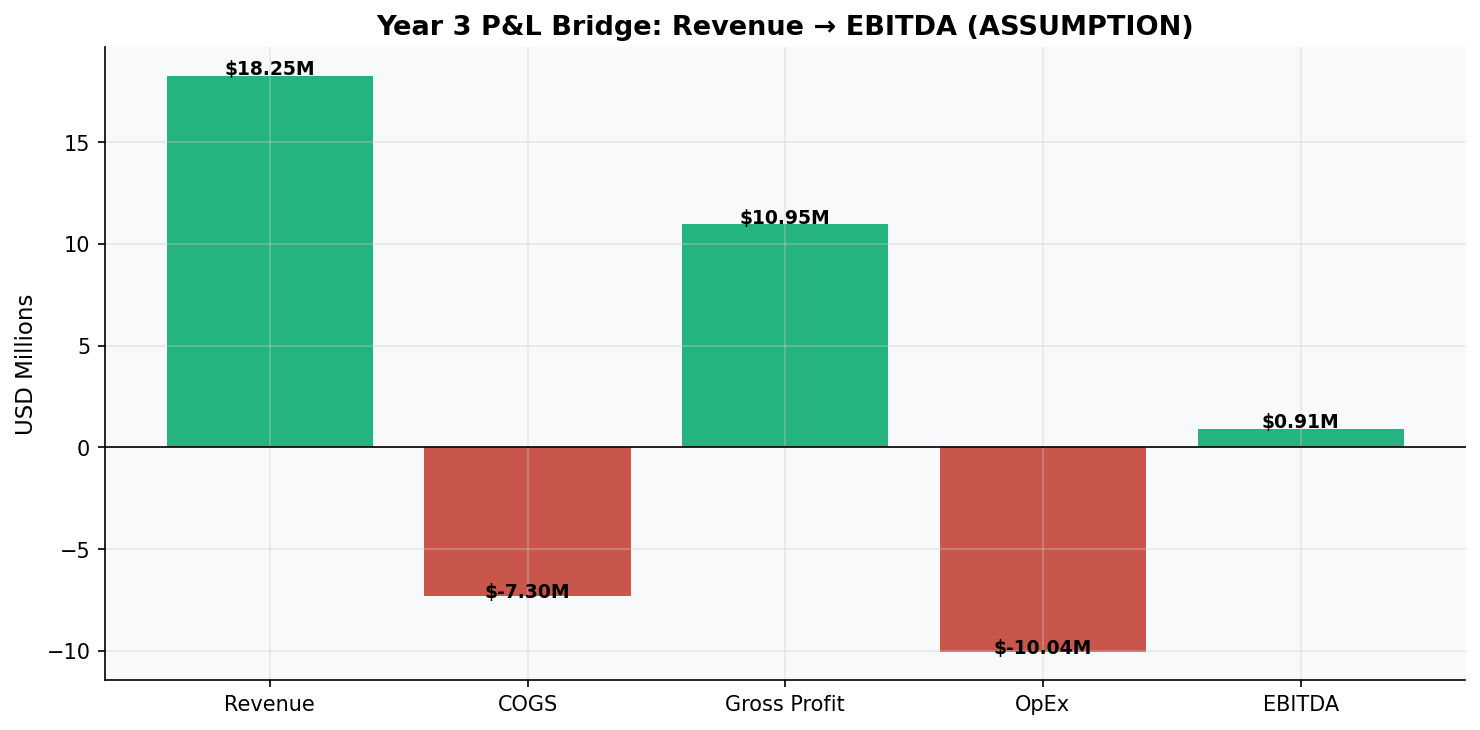

In [6]:
# Bridge chart: Revenue → EBITDA for Year 3
fig, ax = plt.subplots(figsize=(10, 5))
y3 = df_pnl.iloc[-1]
components = [
    ('Revenue',       y3['revenue_usd_m'],        True),
    ('COGS',         -y3['cogs_usd_m'],            False),
    ('Gross Profit',  y3['gross_profit_usd_m'],    True),
    ('OpEx',         -y3['total_opex_usd_m'],      False),
    ('EBITDA',        y3['ebitda_usd_m'],          True),
]
labels = [c[0] for c in components]
values = [c[1] for c in components]
colors = [BRAND_COLORS['secondary'] if c[2] else BRAND_COLORS['danger'] for c in components]

ax.bar(labels, values, color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("USD Millions")
ax.set_title("Year 3 P&L Bridge: Revenue → EBITDA (ASSUMPTION)")
for i, (label, val, _) in enumerate(components):
    ax.text(i, val + (0.05 if val >= 0 else -0.1),
            f"${val:.2f}M", ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
save_figure(fig, "fig12_pnl_bridge_y3.png")
plt.show()

## Sensitivity Analysis

In [7]:
# 2-variable sensitivity: ARPU × Year-3 user count
arpu_range  = [6, 8, 10, 12, 14, 16, 18, 20]
users_range = [500_000, 750_000, 1_000_000, 1_500_000, 2_000_000, 3_000_000]

df_sens_rev = sensitivity_revenue(arpu_range, users_range)
print("SENSITIVITY: Year-3 Revenue (USD M) by ARPU × User Count")
display(df_sens_rev)
df_sens_rev.to_csv(tables_dir / "sensitivity_revenue.csv")

SENSITIVITY: Year-3 Revenue (USD M) by ARPU × User Count


,0.5M users,0.8M users,1.0M users,1.5M users,2.0M users,3.0M users
$6 ARPU,3.0,4.5,6.0,9.0,12.0,18.0
$8 ARPU,4.0,6.0,8.0,12.0,16.0,24.0
$10 ARPU,5.0,7.5,10.0,15.0,20.0,30.0
$12 ARPU,6.0,9.0,12.0,18.0,24.0,36.0
$14 ARPU,7.0,10.5,14.0,21.0,28.0,42.0
$16 ARPU,8.0,12.0,16.0,24.0,32.0,48.0
$18 ARPU,9.0,13.5,18.0,27.0,36.0,54.0
$20 ARPU,10.0,15.0,20.0,30.0,40.0,60.0



SENSITIVITY: EBITDA Margin (%) by ARPU × COGS %


,COGS 30%,COGS 35%,COGS 40%,COGS 45%,COGS 50%
$8 ARPU,15.0,10.0,5.0,0.0,-5.0
$10 ARPU,15.0,10.0,5.0,0.0,-5.0
$12 ARPU,15.0,10.0,5.0,0.0,-5.0
$14 ARPU,15.0,10.0,5.0,0.0,-5.0
$16 ARPU,15.0,10.0,5.0,0.0,-5.0
$20 ARPU,15.0,10.0,5.0,0.0,-5.0


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig13_ebitda_sensitivity.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig13_ebitda_sensitivity.pdf


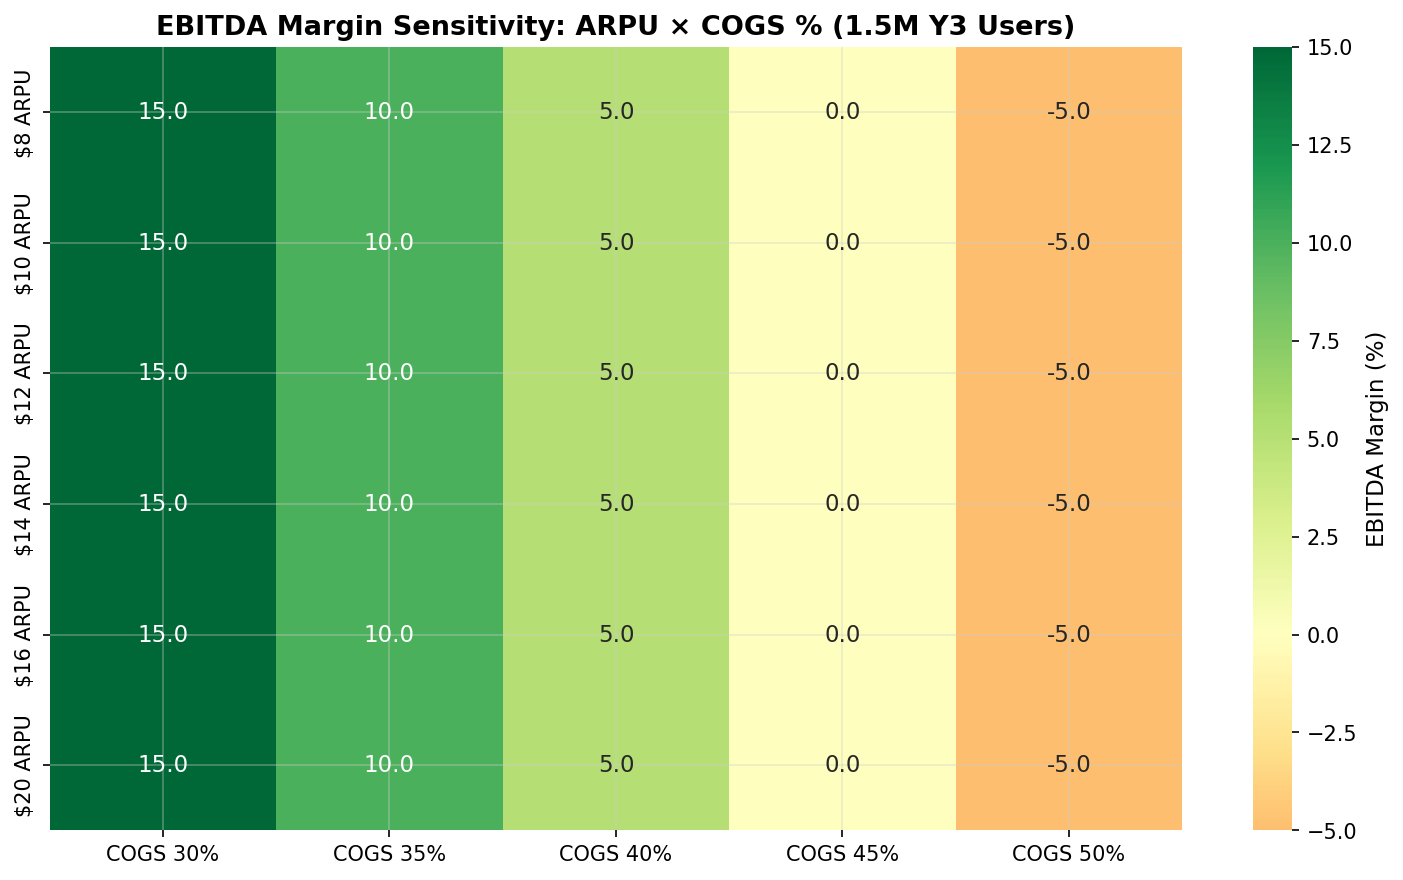

In [8]:
# EBITDA margin sensitivity: ARPU × COGS %
arpu_range2 = [8, 10, 12, 14, 16, 20]
cogs_range  = [0.30, 0.35, 0.40, 0.45, 0.50]

df_sens_ebitda = sensitivity_ebitda(arpu_range2, cogs_range, base_users_y3=1_500_000)
print("\nSENSITIVITY: EBITDA Margin (%) by ARPU × COGS %")
display(df_sens_ebitda)
df_sens_ebitda.to_csv(tables_dir / "sensitivity_ebitda.csv")

import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))
numeric = df_sens_ebitda.applymap(float)
sns.heatmap(numeric, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=ax, cbar_kws={'label': 'EBITDA Margin (%)'})
ax.set_title("EBITDA Margin Sensitivity: ARPU × COGS % (1.5M Y3 Users)")
plt.tight_layout()
save_figure(fig, "fig13_ebitda_sensitivity.png")
plt.show()

## Comparable Company Valuation

In [9]:
# Using Year-3 projected revenue for the valuation
y3_revenue = float(df_revenue.iloc[-1]['total_revenue_usd_m'])
df_valuation = comparable_valuation(y3_revenue)

print(f"Year-3 Projected Revenue: ${y3_revenue:.3f}M")
print()
print("COMPARABLE COMPANY VALUATION — APPROXIMATION:")
print("These multiples are from public sources and must be treated as indicative only.")
display(df_valuation)
df_valuation.to_csv(tables_dir / "comparable_valuation.csv", index=False)

Year-3 Projected Revenue: $18.254M

COMPARABLE COMPANY VALUATION — APPROXIMATION:
These multiples are from public sources and must be treated as indicative only.


,Comparable Company,EV/Revenue Multiple,Implied EV (USD M),Implied EV (NGN B),Source Notes
0,MTN MoMo (listed),5.0x,$91.3M,₦136.9B,MTN Group Annual Report 2023 — mobile money se...
1,Interswitch (pre-IPO est.),6.0x,$109.5M,₦164.3B,Analyst estimates from financial press — APPRO...
2,Flutterwave (last round),8.0x,$146.0M,₦219.0B,Last disclosed funding round vs estimated ARR ...
3,PalmPay (conservative),4.0x,$73.0M,₦109.5B,Funding round valuation vs estimated GMV — APP...
4,Sector median,5.5x,$100.4M,₦150.6B,Median of above comparables


## Excel Export

In [10]:
excel_path = processed_dir / "financial_model.xlsx"

export_to_excel(
    df_users=df_users,
    df_revenue=df_revenue,
    df_pnl=df_pnl,
    df_sensitivity=df_sens_rev,
    df_valuation=df_valuation,
    output_path=excel_path,
)
print(f"\nExcel financial model: {excel_path}")
print("Open this file for the formatted consulting-grade workbook.")

Financial model exported to C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\data\processed\financial_model.xlsx

Excel financial model: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\data\processed\financial_model.xlsx
Open this file for the formatted consulting-grade workbook.
